In [1]:
!pip install opencv-python scikit-image scikit-learn matplotlib



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
import cv2
import numpy as np
from skimage.feature import local_binary_pattern
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC


In [6]:
import os

DATASET_PATH = "."

total = 0

for surface in ["Decks", "Pavements", "Walls"]:
    surface_path = os.path.join(DATASET_PATH, surface)

    for category in os.listdir(surface_path):
        category_path = os.path.join(surface_path, category)

        for file in os.listdir(category_path):
            if file.endswith(".jpg"):
                total += 1

print("Total Images:", total)

Total Images: 16864


In [23]:
print("Original:", img.shape)
print("Resized:", resized.shape)

Original: (256, 256, 3)
Resized: (256, 256, 3)


In [24]:
sizes = set()

for surface in ["Decks", "Pavements", "Walls"]:
    surface_path = os.path.join(DATASET_PATH, surface)

    for category in os.listdir(surface_path):
        category_path = os.path.join(surface_path, category)

        for file in os.listdir(category_path):
            if file.endswith(".jpg"):
                img = cv2.imread(os.path.join(category_path, file))
                sizes.add(img.shape)

print("Different Image Sizes:", sizes)

Different Image Sizes: {(256, 256, 3)}


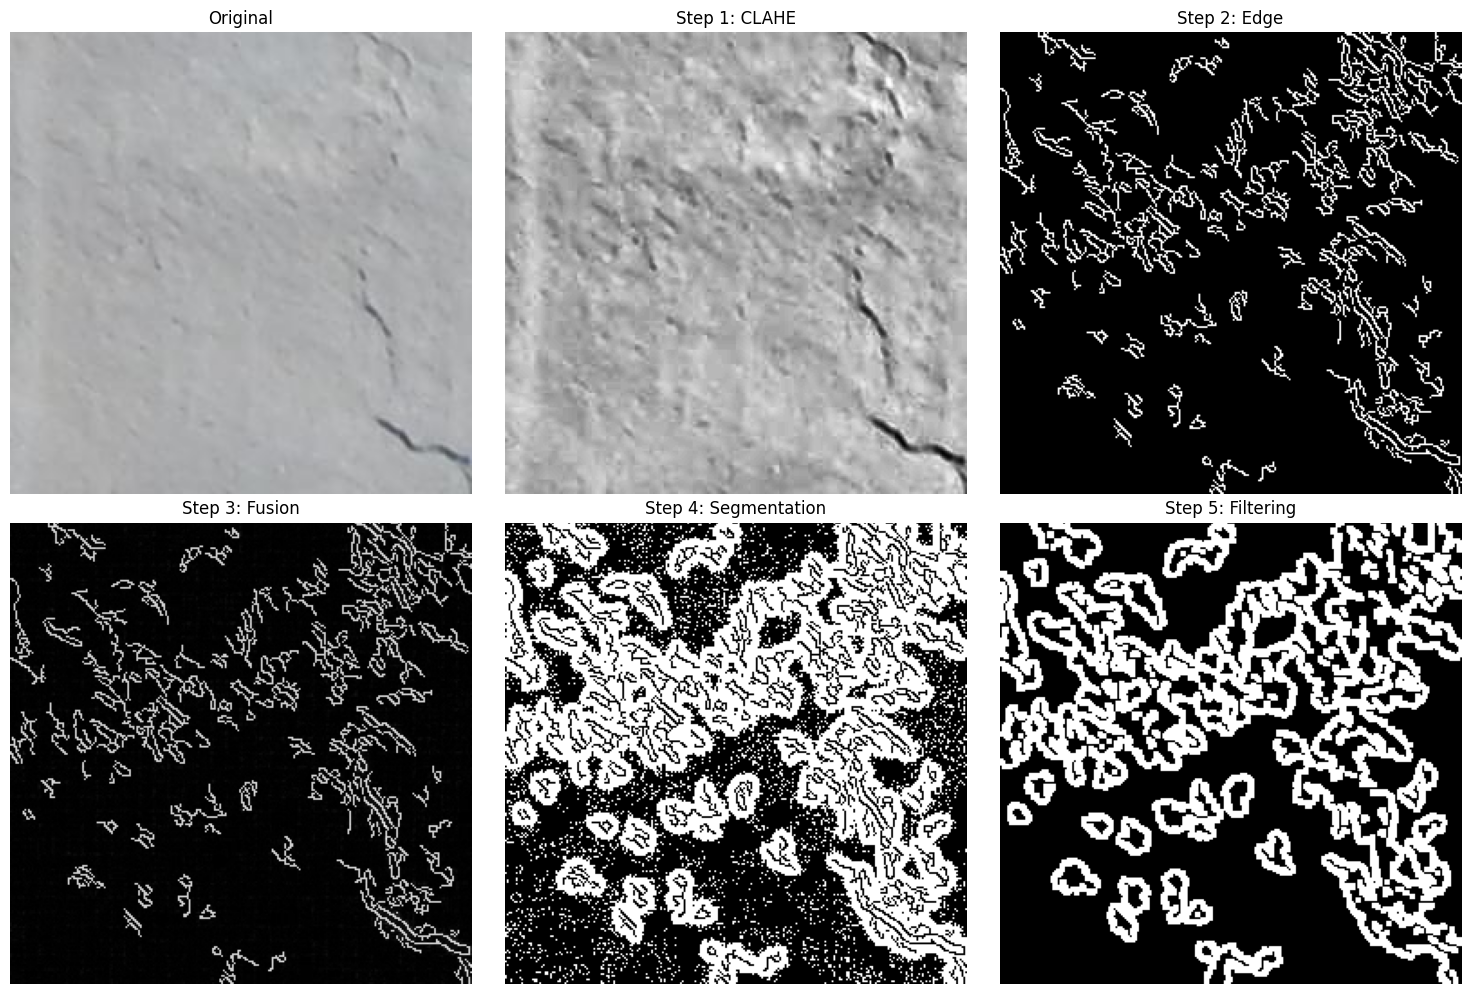

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --------- Load Image (FIXED) ----------
IMAGE_PATH = r"Decks/Cracked/7001-2.jpg"
img = cv2.imread(IMAGE_PATH)

if img is None:
    print("Image not found. Check path!")
else:
    plt.figure(figsize=(15,10))

    # =========================
    # STEP 1: PREPROCESSING
    # =========================
    
    plt.subplot(2,3,1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    processed = clahe.apply(gray)

    plt.subplot(2,3,2)
    plt.imshow(processed, cmap='gray')
    plt.title("Step 1: CLAHE")
    plt.axis("off")


    # =========================
    # STEP 2: FEATURE EXTRACTION
    # =========================
    
    edges = cv2.Canny(processed, 50, 150)

    texture = cv2.Laplacian(processed, cv2.CV_64F)
    texture = cv2.convertScaleAbs(texture)

    plt.subplot(2,3,3)
    plt.imshow(edges, cmap='gray')
    plt.title("Step 2: Edge")
    plt.axis("off")


    # =========================
    # STEP 3: FEATURE FUSION
    # =========================
    
    fused = cv2.addWeighted(edges, 0.7, texture, 0.3, 0)

    plt.subplot(2,3,4)
    plt.imshow(fused, cmap='gray')
    plt.title("Step 3: Fusion")
    plt.axis("off")


    # =========================
    # STEP 4: SEGMENTATION
    # =========================
    
    segmented = cv2.adaptiveThreshold(
        fused,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        11,
        2
    )

    plt.subplot(2,3,5)
    plt.imshow(segmented, cmap='gray')
    plt.title("Step 4: Segmentation")
    plt.axis("off")


    # =========================
    # STEP 5: ORIENTATION FILTERING
    # =========================
    
    kernel = np.ones((3,3), np.uint8)
    cleaned = cv2.morphologyEx(segmented, cv2.MORPH_OPEN, kernel)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(cleaned)

    filtered = np.zeros_like(cleaned)
    min_length = 50

    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] > min_length:
            filtered[labels == i] = 255

    plt.subplot(2,3,6)
    plt.imshow(filtered, cmap='gray')
    plt.title("Step 5: Filtering")
    plt.axis("off")

    plt.tight_layout()
    plt.show()
  


In [12]:
import os
print(os.getcwd())

C:\Users\purni\computer vision


In [22]:
import os
import cv2
import numpy as np

INPUT_PATH = r"Decks"   # change to your root dataset folder
OUTPUT_BASE = r"processed_output"

CATEGORIES = ["Decks", "Pavements", "Walls"]
CLASSES = ["Cracked", "Non-Cracked"]

def create_structure(base_path):
    for cat in CATEGORIES:
        for cls in CLASSES:
            os.makedirs(os.path.join(base_path, cat, cls), exist_ok=True)

In [23]:
OUTPUT_PATH = os.path.join(OUTPUT_BASE, "step1_preprocessing")
create_structure(OUTPUT_PATH)

for cat in CATEGORIES:
    for cls in CLASSES:
        input_folder = os.path.join(cat, cls)
        output_folder = os.path.join(OUTPUT_PATH, cat, cls)

        for file in os.listdir(input_folder):
            if file.endswith(".jpg"):
                img_path = os.path.join(input_folder, file)
                img = cv2.imread(img_path)

                if img is None:
                    continue

                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
                processed = clahe.apply(gray)

                cv2.imwrite(os.path.join(output_folder, file), processed)

print(" Step 1 completed")

 Step 1 completed


In [24]:
INPUT_STEP = os.path.join(OUTPUT_BASE, "step1_preprocessing")
OUTPUT_PATH = os.path.join(OUTPUT_BASE, "step2_features")
create_structure(OUTPUT_PATH)

for cat in CATEGORIES:
    for cls in CLASSES:
        input_folder = os.path.join(INPUT_STEP, cat, cls)
        output_folder = os.path.join(OUTPUT_PATH, cat, cls)

        for file in os.listdir(input_folder):
            if file.endswith(".jpg"):
                img = cv2.imread(os.path.join(input_folder, file), 0)

                edges = cv2.Canny(img, 50, 150)
                texture = cv2.Laplacian(img, cv2.CV_64F)
                texture = cv2.convertScaleAbs(texture)

                combined = cv2.hconcat([edges, texture])
                cv2.imwrite(os.path.join(output_folder, file), combined)

print(" Step 2 completed")

 Step 2 completed


In [25]:
INPUT_STEP = os.path.join(OUTPUT_BASE, "step2_features")
OUTPUT_PATH = os.path.join(OUTPUT_BASE, "step3_fusion")
create_structure(OUTPUT_PATH)

for cat in CATEGORIES:
    for cls in CLASSES:
        input_folder = os.path.join(INPUT_STEP, cat, cls)
        output_folder = os.path.join(OUTPUT_PATH, cat, cls)

        for file in os.listdir(input_folder):
            if file.endswith(".jpg"):
                img = cv2.imread(os.path.join(input_folder, file), 0)

                h, w = img.shape
                edges = img[:, :w//2]
                texture = img[:, w//2:]

                fused = cv2.addWeighted(edges, 0.7, texture, 0.3, 0)
                cv2.imwrite(os.path.join(output_folder, file), fused)

print("Step 3 completed")

Step 3 completed


In [26]:
INPUT_STEP = os.path.join(OUTPUT_BASE, "step3_fusion")
OUTPUT_PATH = os.path.join(OUTPUT_BASE, "step4_segmentation")
create_structure(OUTPUT_PATH)

for cat in CATEGORIES:
    for cls in CLASSES:
        input_folder = os.path.join(INPUT_STEP, cat, cls)
        output_folder = os.path.join(OUTPUT_PATH, cat, cls)

        for file in os.listdir(input_folder):
            if file.endswith(".jpg"):
                img = cv2.imread(os.path.join(input_folder, file), 0)

                segmented = cv2.adaptiveThreshold(
                    img, 255,
                    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                    cv2.THRESH_BINARY_INV,
                    11, 2
                )

                cv2.imwrite(os.path.join(output_folder, file), segmented)

print("Step 4 completed")

Step 4 completed


In [27]:
INPUT_STEP = os.path.join(OUTPUT_BASE, "step4_segmentation")
OUTPUT_PATH = os.path.join(OUTPUT_BASE, "step5_filtered")
create_structure(OUTPUT_PATH)

for cat in CATEGORIES:
    for cls in CLASSES:
        input_folder = os.path.join(INPUT_STEP, cat, cls)
        output_folder = os.path.join(OUTPUT_PATH, cat, cls)

        for file in os.listdir(input_folder):
            if file.endswith(".jpg"):
                img = cv2.imread(os.path.join(input_folder, file), 0)

                kernel = np.ones((3,3), np.uint8)
                cleaned = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)

                num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(cleaned)

                filtered = np.zeros_like(cleaned)

                for i in range(1, num_labels):
                    if stats[i, cv2.CC_STAT_AREA] > 50:
                        filtered[labels == i] = 255

                cv2.imwrite(os.path.join(output_folder, file), filtered)

print("Step 5 completed")

Step 5 completed
